In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")

✅ Libraries ready!


In [2]:
# ── Scrape Books to Scrape ─────────────────────────────────
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scrape multiple pages
base_url = "https://books.toscrape.com/catalogue/page-{}.html"
books = []

print("Scraping books... please wait!")

for page in range(1, 21):  # First 20 pages = 400 books
    url = base_url.format(page)
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    
    for book in soup.find_all('article', class_='product_pod'):
        title = book.h3.a['title']
        price = book.find('p', class_='price_color').text.strip()
        rating = book.p['class'][1]
        availability = book.find('p', class_='instock').text.strip()
        
        books.append({
            'Title': title,
            'Price': price,
            'Rating': rating,
            'Availability': availability
        })

df_books = pd.DataFrame(books)
print(f"✅ Scraped {len(df_books)} books!")
print(f"\nColumns: {df_books.columns.tolist()}")
df_books.head()

Scraping books... please wait!
✅ Scraped 400 books!

Columns: ['Title', 'Price', 'Rating', 'Availability']


,Title,Price,Rating,Availability
0,A Light in the Attic,£51.77,Three,In stock
1,Tipping the Velvet,£53.74,One,In stock
2,Soumission,£50.10,One,In stock
3,Sharp Objects,£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,£54.23,Five,In stock


In [3]:
# ── Clean Data ─────────────────────────────────────────────
# Convert price to number
df_books['Price'] = df_books['Price'].str.replace('£', '').astype(float)

# Convert rating to number
rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df_books['Rating_Num'] = df_books['Rating'].map(rating_map)

print("✅ Data cleaned!")
print(f"\nPrice range: £{df_books['Price'].min()} to £{df_books['Price'].max()}")
print(f"Average price: £{df_books['Price'].mean():.2f}")
print(f"\nRating distribution:")
print(df_books['Rating'].value_counts())

✅ Data cleaned!

Price range: £10.16 to £59.9
Average price: £34.96

Rating distribution:
Rating
One      88
Two      82
Three    80
Five     77
Four     73
Name: count, dtype: int64


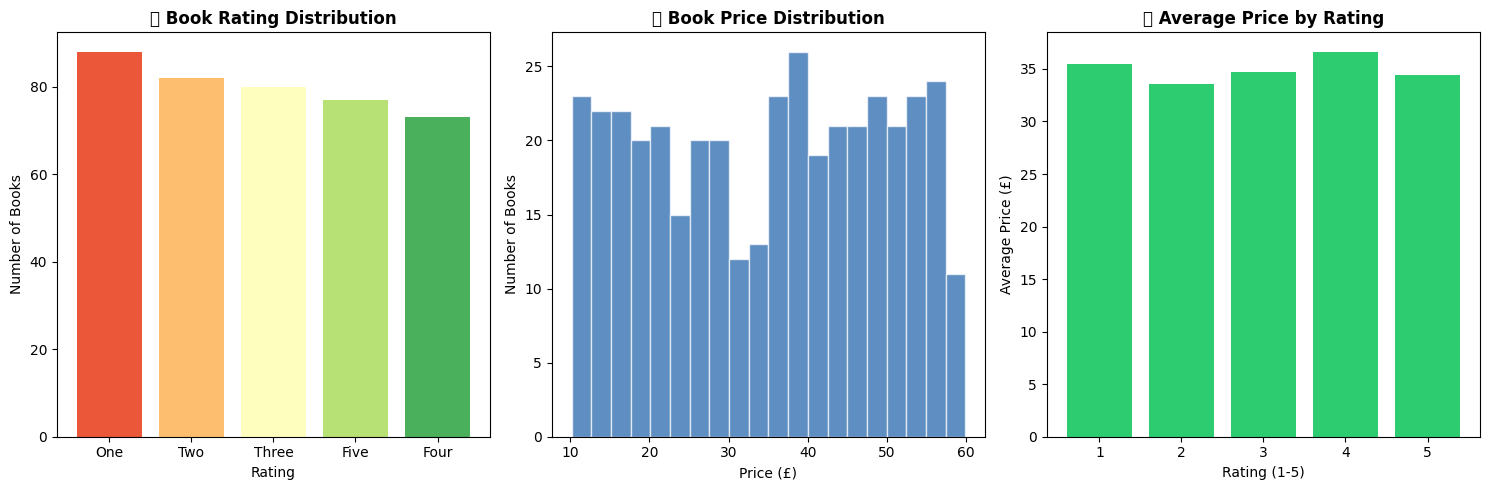

✅ Charts saved!
✅ Data saved to CSV!


In [4]:
# ── Charts ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Rating Distribution
rating_counts = df_books['Rating'].value_counts()
axes[0].bar(rating_counts.index, rating_counts.values, 
            color=sns.color_palette('RdYlGn', 5))
axes[0].set_title('⭐ Book Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Books')

# Chart 2: Price Distribution
axes[1].hist(df_books['Price'], bins=20, color='#1a5fa8', alpha=0.7, edgecolor='white')
axes[1].set_title('💰 Book Price Distribution', fontweight='bold')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Number of Books')

# Chart 3: Average Price by Rating
avg_price = df_books.groupby('Rating_Num')['Price'].mean()
axes[2].bar(avg_price.index, avg_price.values, color='#2ecc71')
axes[2].set_title('📊 Average Price by Rating', fontweight='bold')
axes[2].set_xlabel('Rating (1-5)')
axes[2].set_ylabel('Average Price (£)')

plt.tight_layout()
plt.savefig('books_analysis.png', dpi=150)
plt.show()
print("✅ Charts saved!")

# Save to CSV
df_books.to_csv('scraped_books.csv', index=False)
print("✅ Data saved to CSV!")